In [14]:
import pandas as pd
import numpy as np
from ipywidgets import widgets, ButtonStyle, Layout
from IPython.display import HTML, display, clear_output

In [2]:
def seggregate_numeric_discrete(data, max_count=15):
    try:
        discrete_columns = data.nunique() < max_count
        continous_columns = np.invert(discrete_columns)
        discrete_columns = data.loc[:, discrete_columns].columns
        continous_columns = data.loc[:, continous_columns].columns
    except:
        discrete_columns = [None]
        continous_columns = [None]
    discrete_columns = list(discrete_columns)
    continous_columns = list(continous_columns)
    name_columns = [i for i in list(continous_columns) if i.lower().__contains__("name")]
    address_columns = [i for i in list(continous_columns) if i.lower().__contains__("addr")]
    name_columns = name_columns if len(name_columns) > 0 else ["None"]
    address_columns = address_columns if len(address_columns) > 0 else ["None"]
    continous_columns = [i for i in continous_columns if i not in name_columns]
    continous_columns = [i for i in continous_columns if i not in address_columns]
    return discrete_columns, continous_columns, name_columns, address_columns
def set_headings(heading):
    out = widgets.Output(layout={'width': '100%'})
    out.append_stdout(heading)
    return out
def processing_values(validating_value, dependent_var, independent_var_1, independent_var_2, independent_var_3):
    if validating_value not in dependent_var:
        dependent_var += [validating_value]
        
    if validating_value in independent_var_1:
        independent_var_1.remove(validating_value)        
    elif validating_value in independent_var_2:
        independent_var_2.remove(validating_value)        
    elif validating_value in independent_var_3:
        independent_var_3.remove(validating_value)
        
    return dependent_var, independent_var_1, independent_var_2, independent_var_3

In [162]:
class processing:
    def __init__(self):
        self.df = pd.read_csv("D:\Projects\Synthetic Data Generation\dataprivacy\sampledata\HR_address_data.csv")
        self.discrete, self.continous, self.name, self.address = seggregate_numeric_discrete(self.df, max_count=15)
        self.features = self.df.columns.values
        
        
    def create_selection_widgets(self):
        self.feature_headings = set_headings("Features")
        self.features_selection = widgets.SelectMultiple(
                    options=self.features,
                    value=[],
                    rows=30,
                    disabled=False,
                    layout = {"width":"90%"}
                )
        self.continous_headings = set_headings("Continous")
        self.continous_selection = widgets.SelectMultiple(
                    options=self.continous,
                    value=[],
                    rows=5,
                    disabled=True,
                    layout = {"width":"90%"}
                )
        self.discrete_headings = set_headings("Discrete")
        self.discrete_selection = widgets.SelectMultiple(
                    options=self.discrete,
                    value=[],
                    rows=5,
                    disabled=True,
                    layout = {"width":"90%"}
                )
        self.name_heading = set_headings("Name")
        self.name_selection = widgets.SelectMultiple(
                    options=self.name,
                    value=[],
                    rows=5,
                    disabled=True,
                    layout = {"width":"90%"}
                )
        self.address_headings = set_headings("Address")
        self.address_selection = widgets.SelectMultiple(
                    options=self.address,
                    value=[],
                    rows=5,
                    disabled=True,
                    layout = {"width":"90%"}
                )
        
        
    def create_button_widgets(self):
        self.reset_button = widgets.Button(description=f'Reset to Empty', 
                                           style=ButtonStyle(button_color='orange'), 
                                           layout={'width': '70%'}, tooltip='Reset to Empty')
        self.continous_button = widgets.Button(description=f'Continous', 
                                               style=ButtonStyle(button_color='orange'), 
                                               layout={'width': '70%'}, tooltip='Continous')
        self.discrete_button = widgets.Button(description=f'Discrete', 
                                              style=ButtonStyle(button_color='orange'), 
                                              layout={'width': '70%'}, tooltip='Discrete')
        self.name_button = widgets.Button(description=f'Name', 
                                          style=ButtonStyle(button_color='orange'), 
                                          layout={'width': '70%'}, tooltip='Discrete')
        self.address_button = widgets.Button(description=f'Address', 
                                             style=ButtonStyle(button_color='orange'), 
                                             layout={'width': '70%'},tooltip='Address')
        self.preselect_button = widgets.Button(description=f'Reset to Pre-select', 
                                               style=ButtonStyle(button_color='orange'), 
                                               layout={'width': '70%'}, tooltip='Reset to Pre-select')
        self.finish_button = widgets.Button(description=f'Finish Feature Selection', 
                                              style=ButtonStyle(button_color='orange'), 
                                              layout={'width': '50%'},tooltip='Finish Feature Selection')
        
        self.reset_button.on_click(self.reset)
        self.continous_button.on_click(self.continous_feat_drag)
        self.discrete_button.on_click(self.discrete_feat_drag)
        self.name_button.on_click(self.name_feat_drag)
        self.address_button.on_click(self.address_feat_drag)
        self.finish_button.on_click(self.finish_data_selection)
        self.preselect_button.on_click(self.preselect)
        
    def display_data_processing(self):
        self.create_selection_widgets()
        self.create_button_widgets()
        clear_output()
        self.data_processing_output = widgets.Output()
        box_layout = widgets.Layout(display='flex',
                flex_flow='column',
                align_items='flex-start',
                width='100%')
        output_layout = widgets.Layout(display='flex',
                flex_flow='column',
                align_items='center',
                width='100%')
        row_box_layout = widgets.Layout(display='flex',
                flex_flow='column',
                align_items='center',
                width='100%', 
                justify_content = 'center')
        feature_box = widgets.VBox([self.feature_headings, 
                                    self.features_selection], layout=box_layout)
        button_box = widgets.VBox([self.reset_button, self.continous_button, 
                                   self.discrete_button, self.name_button, 
                                   self.address_button, self.preselect_button], layout=row_box_layout)
        disc_cont_box = widgets.VBox([self.discrete_headings, self.discrete_selection, 
                                      self.continous_headings, self.continous_selection], layout=box_layout)
        name_addr_box = widgets.VBox([self.name_heading, self.name_selection, 
                                      self.address_headings, self.address_selection], layout=box_layout)
        h1 = widgets.HBox([feature_box, button_box, disc_cont_box, name_addr_box])
        h2 = widgets.HBox([self.finish_button, self.data_processing_output], layout=row_box_layout)
        display(h1)
        display(h2)
    
    def set_options(self):
        self.continous_selection.options = self.continous
        self.discrete_selection.options = self.discrete
        self.name_selection.options = self.name
        self.address_selection.options = self.address
        
    def reset(self,_):
        self.discrete = []
        self.continous = []
        self.name = []
        self.address = []
        self.set_options()
        
    def continous_feat_drag(self,_):
        for i in self.features_selection.value:
            self.continous, self.discrete, self.name, self.address = processing_values(i, 
                                                                                       self.continous, 
                                                                                       self.discrete, 
                                                                                       self.name, 
                                                                                       self.address)
        self.set_options()
        
    def discrete_feat_drag(self,_):
        for i in self.features_selection.value:
            self.discrete, self.continous, self.name, self.address = processing_values(i, 
                                                                                       self.discrete,
                                                                                       self.continous, 
                                                                                       self.name, 
                                                                                       self.address)
        self.set_options()
        
    def name_feat_drag(self,_):
        for i in self.features_selection.value:
            self.name, self.continous, self.discrete, self.address = processing_values(i,
                                                                                       self.name,
                                                                                       self.continous, 
                                                                                       self.discrete, 
                                                                                       self.address)
        self.set_options()
        
    def address_feat_drag(self,_):
        for i in self.features_selection.value:
            self.address, self.continous, self.discrete, self.name = processing_values(i, 
                                                                                       self.address,
                                                                                       self.continous, 
                                                                                       self.discrete, 
                                                                                       self.name)
        self.set_options()
    
    def preselect(self,_):
        self.discrete, self.continous, self.name, self.address = seggregate_numeric_discrete(self.df, max_count=15)
        self.set_options()
        
    def finish_data_selection(self,_):
        with self.data_processing_output:
            clear_output()
            try:
                processedDF, encodedDf, discreteLabelEncoders = process_data(data = self.df,  
                                                                             numericalColumns = self.continous, 
                                                                             discreteColumns = self.discrete, 
                                                                             nameColumns = self.name, 
                                                                             addressColumns = self.addess)
                display(HTML(f'<h4 style="color:green" style="align:center">Feature Selection Sucess!<h4>'))
                self.processedData = processedDF
                self.encodedDf = encodedDf
                self.discreteLabelEncoders = discreteLabelEncoders
                self.discreteColumns = None if len(self.discrete) == 0 else self.discrete
                self.nameColumns = None if len(self.name) == 0 else self.name
                self.addressColumns = None if len(self.addess) == 0 else self.addess
                self.numericalColumns = None if len(self.continous) == 0 else self.continous
            except AssertionError as msg:
                display(HTML(f'<h4 style="color:red" style="align:center">**{msg}**</h4><hr>'))

In [163]:
dp = processing()
dp.display_data_processing()

In [8]:
def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        print("changed to %s" % change['new'])

In [116]:
models_selection = widgets.Dropdown(
    options=[('GC', "gc"), ('TVAE', "tvae"), ('CTGAN', "ctgan")],
    value="gc",
    description='Select Model:',
)
models_selection.observe(on_change)
h = widgets.HBox([models_selection])
model_codes = f'''<details>
<summary><b> &lt;&lt;  CLICK HERE to expand / collapse Section Overview &gt;&gt; </b></summary>
<h5 class="code-line" data-line-start="0" data-line-end="1"><a id="GC_0"></a>GC:</h5>
<ul>
<li class="has-line-data" data-line-start="1" data-line-end="2">Gaussian Coupla</li>
<li class="has-line-data" data-line-start="2" data-line-end="4">Lorem Ipsum</li>
</ul>
<h5 class="code-line" data-line-start="4" data-line-end="5"><a id="CTGAN_4"></a>CTGAN:</h5>
<ul>
<li class="has-line-data" data-line-start="5" data-line-end="6">Cross Sectional Tabular Gan</li>
<li class="has-line-data" data-line-start="6" data-line-end="8">Lorem Ipsum</li>
</ul>
<h5 class="code-line" data-line-start="8" data-line-end="9"><a id="TVAE_8"></a>TVAE:</h5>
<ul>
<li class="has-line-data" data-line-start="9" data-line-end="10">T-Variational Auto-Encoder</li>
<li class="has-line-data" data-line-start="10" data-line-end="12">Lorem Ipsum</li>
</ul>
<p style="text-align: center">
    <div class="lm-Widget p-Widget jupyter-widgets widget-inline-hbox widget-dropdown">
        <label class="widget-label" style="" title="Select Model:" for="93647952-555d-42bc-8003-6ccf36048a39">Select Model:</label>
        <select id="93647952-555d-42bc-8003-6ccf36048a39">
            <option data-value="GC" value="GC">GC</option>
            <option data-value="TVAE" value="TVAE">TVAE</option>
            <option data-value="CTGAN" value="CTGAN">CTGAN</option>
        </select>
    </div>
</p>
</details>
'''
display(HTML(model_codes))

<class 'pandas.core.frame.DataFrame'>


Text(0.5, 1.0, 'Private Data Age vs. MonthlyIncome')

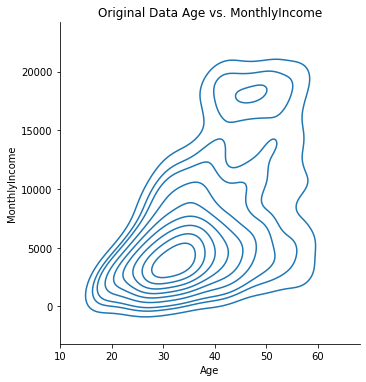

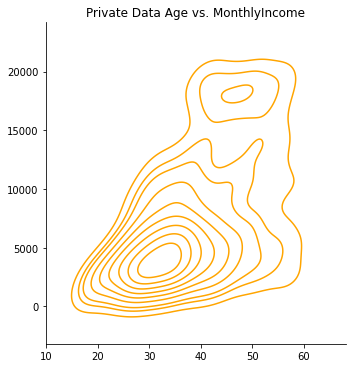

In [194]:
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import *
df = pd.read_csv("D:\Projects\Synthetic Data Generation\dataprivacy\sampledata\HR_address_data.csv")
privateData = df.copy()
x = "Age"
y = "MonthlyIncome"
print(type(privateData))
# plt.figure(figsize=(14, 5))
# plt.title(f'Original Data {x} vs. {y}')
sns.displot(x=df[x].values, y=df[y].values, kind="kde")
plt.title(f'Original Data {x} vs. {y}')
plt.xlabel(x)
plt.ylabel(y)
sns.displot(x = privateData[x].values, y = privateData[y].values, color="orange", kind="kde")
plt.title(f'Private Data {x} vs. {y}')
# plt.xlabel(x)
# plt.ylabel(y)


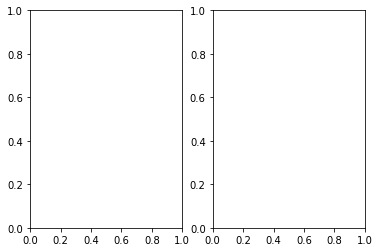

In [180]:
ax, ax1 = plt.subplots(1,2)

In [129]:
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

def model_setup():
    def operation_handler(option):
        try:
            if option == 'GC Model':
#                 outer_box_layout = Layout(display='flex',
#                                           flex_flow='row',
#                                           align_items='stretch',
#                                           border='solid',
#                                           margin="10px 0px 10px 0px",
#                                           width='800px')
#                 box_title = widgets.Button(description="GC Model Settings", layout=Layout(width= '300px'), 
#                                            style= {"button_color":'#FFFFFF', "font_weight":'bold'})
#                 gc_tune = widgets.Button(description='Gaussian Coupla model doesn\'t require any hyper-parameter tuning.', 
#                                              layout=Layout(width= '200%'), button_style="success")
#                 box = widgets.HBox([gc_tune], layout=outer_box_layout)
#                 display(widgets.VBox([box_title, box], layout=Layout(display='flex', flex_flow='column', align_items="center")))
                gc_tuning_html_codes = '''<div class="output" style="">
                        <div class="output_area"><div class="output_subarea output_text output_stream output_stdout" dir="auto">
                        <pre><span class="ansi-green-intense-fg ansi-bold">
                            Gaussian Coupla model doesn't require any hyper-parameter tuning.
                        </span></pre></div></div></div>'''
                display(widgets.HTML(gc_tuning_html_codes))
#                 print("\n\n\n",color.BOLD + color.GREEN + "Gaussian Coupla model doesn't require any hyper-parameter tuning." + color.END)
                                          
            elif option == 'TVAE Model':
                box_layout = widgets.Layout(display='flex',flex_flow='row')
                outer_box_layout = Layout(display='flex',
                                          flex_flow='column',
                                          align_items='stretch',
                                          border='solid',
                                          margin="10px 0px 10px 0px",
                                          width='100%')
                style = {'description_width': '150px'}
                layout = {'width': '20px'}
                box_title = widgets.HTML("<p style='width: 300px'><center style='color:orange'><b>TVAE Model Settings</></center></p>")
#                 widgets.Button(description="TVAE Model Settings", layout=Layout(width= '300px'), 
#                                            style= {"button_color":'#FFFFFF', "font_weight":'bold'})
            
#                 epoch_range = widgets.Button(description='Ideal Range: [1000,2000,3000,4000,5000]', 
#                                              layout=Layout(width= '300px'), 
#                                            style= { "color":'red'}, button_style="info")
                epoch_range = widgets.HTML("<p style='width: 300px'><center style='color:#5d5dfffa'>Ideal Range: [1000,2000,3000,4000,5000]</center></p>")
                epoch_selection = widgets.IntText(value=1000,description='<b>Epoch:</b>',  disabled=False, style=style)

                batch_range = widgets.Button(description='Ideal Range: [32, 64,128,256,512,1024]', 
                                             layout=Layout(width= '300px'), 
                                           style= { "color":'red'}, button_style="info")
                batch_size_selection = widgets.IntText(value=32,description='<b>Batch Size:</b>',  disabled=False, style=style)
                lr_range = widgets.Button(description='Ideal Range: [0.0001, 0.001, 0.01, 0.1]', 
                                          layout=Layout(width= '300px'),
                                           style= { "color":'red'}, button_style="info")
                lr_selection = widgets.BoundedFloatText(value = 0.01, min = 0.0, max = 1.0, step = 0.001, 
                                                        description='<b>Learning Rate:</b>',  disabled=False, style=style)

                epoch_h_box = widgets.HBox([epoch_selection, epoch_range])
                batch_h_box = widgets.HBox([batch_size_selection, batch_range]) 
                lr_h_box = widgets.HBox([lr_selection, lr_range])
                box = widgets.VBox([epoch_h_box, batch_h_box, lr_h_box], layout=outer_box_layout)
                display(widgets.VBox([box_title, box], layout=Layout(display='flex', flex_flow='column', align_items="center")))
            else:
                print(color.BOLD + color.GREEN + "This section is currently under development." + color.END)
                
        except Exception as e:
            print(color.BOLD + color.RED + "Error message: " + color.END, end=" "),
            print(e)
                

    option = widgets.RadioButtons(options=['GC Model', 'TVAE Model', 'CT-GAN Model'],value = 'TVAE Model', layout=Layout(margin='5px  10px 10px 50px', width="200px"))

    operation_selection_button = widgets.Button(description='Select Model Type:', layout=Layout(margin='0 10px 0 0', height='30px', width='150px'))
    operation_selection_button.style.button_color = '#FFFFFF'
    operation_selection_button.style.font_weight = 'bold'
    
    out=widgets.interactive_output(operation_handler, {'option': option})

    box = widgets.HBox([widgets.VBox([operation_selection_button, option]), out], layout= box_layout)
    accordion_problem_formulation = widgets.Accordion(children=[box], selected_index=None)
    [accordion_problem_formulation.set_title(i, title) for i, title in enumerate(['Advance Settings'])]
    display(widgets.VBox([accordion_problem_formulation]))

model_setup()

In [140]:
%matplotlib inline
import numpy as np
from scipy.integrate import ode
import matplotlib.pyplot as plt
from ipywidgets import *
from IPython.display import clear_output, display, HTML
#
def fmain (ka, kd):
#  
    num_steps = 10
#  
# Prepare plots 
    fig, ax = plt.subplots()  
#    
    τ = np.zeros((num_steps, 1))
    F = np.zeros(num_steps)  
    τ[0] = 0.
    F[0] = ka + kd*τ[0]
#
# Integrate the system of ODEs across each delta_t timestep
    kk = 1
    while kk < num_steps:     
        τ[kk] = τ[kk-1] + 0.01     
        F[kk] = ka + kd*τ[kk]
#                 
        clear_output(wait=True)
        ax.cla()
        ax.plot(τ[0:kk], F[0:kk], color="blue", linestyle="solid",     linewidth=2)
        ax.set_ylabel(r'Dimensionless exit flow rate, $\bar F_A$  [-]')
        ax.set_xlabel('Dimensionless time, $τ$ [-]')
        ax.set_title('Numerical Simulation ka= %s, kd = %s'%(ka, kd))
        display(fig)
#        
# end of time cycle      
        kk += 1         
#    
plt.close()
# Specify widgets
def test(_):
    ka.value = 10
form = widgets.VBox()
ka = BoundedFloatText(description="$$k_a:$$", 
                             value=5.0, min=0.0, max=30.0,
                             padding = 4)
kd = BoundedFloatText(description="$$k_d:$$", 
                             value=5.0, min=0.0, max=30.0, step=0.5,
                             padding = 4)
button = widgets.Button(description="Click to Run Program",
                    color="red",background_color= "lightgray")
form.children = [ka, kd, button]
display(form)

h4 = widgets.HTML(f"<br><i> Simulation started, be patient!</i>{form}<br>")
def on_button_clicked(b):
    display(h4)
#     fmain(ka.value, kd.value)
#     h4.close()
# button.on_click(on_button_clicked)
button.on_click(test)

In [ ]:
import ipywidgets as widgets
from IPython.display import display

geo={'USA':['CHI','NYC'],'Russia':['MOW','LED']}
geoWs = {key: widgets.Select(options=geo[key]) for key in geo}

def get_current_state():
    return {'country': i.children[0].value,
            'city': i.children[1].value}

def print_city(**func_kwargs):
    print('func_kwargs', func_kwargs)
    print('i.kwargs', i.kwargs)
    print('get_current_state', get_current_state())

def select_country(country):
    new_i = widgets.interactive(print_city, country=countryW, city=geoWs[country['new']])
    i.children = new_i.children

countryW = widgets.Select(options=list(geo.keys()))
init = countryW.value
cityW = geoWs[init]

countryW.observe(select_country, 'value')

i = widgets.interactive(print_city, country=countryW, city=cityW)

display(i)

In [ ]:
#testing adding button and textbox
from ipywidgets import widgets as wd
from ipywidgets import Layout, Box
from IPython.display import display

btnLayout = Layout(flex='1 1 auto', width='auto')

btns= [
    wd.Button(description="Add Route"),
    wd.Button(description="234"),
    wd.Button(description="411")
]

box_layout = Layout(display='flex',
                    flex_flow='row',
                    align_items='stretch')

box = Box(children=btns, layout=box_layout)

display(box)
box.children[1].layout.visibility = 'hidden'
box.children[2].layout.visibility = 'hidden'

txtArea = wd.Textarea()
display(txtArea)

def show(b):
    box.children[1].layout.visibility = 'visible'
    box.children[2].layout.visibility = 'visible'

#function intended to append button value/description to textArea
def add_text(b):
    txtArea.value = b.description + txtArea.value

box.children[0].on_click(show)
box.children[1].on_click(add_text)
box.children[2].on_click(add_text)

In [ ]:
[0,1,2,3] + [4,5]

In [ ]:
l = [0,1,2,3,4]
l.remove(4)
l

In [92]:
import ipywidgets
ipywidgets.__version__

'7.6.5'

In [91]:
!pip install ipywidgets
# !jupyter nbextension enable --py widgetsnbextension

You should consider upgrading via the 'C:\Users\sa35581\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.
